<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/8-Ensambles-micaela-sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q --upgrade --no-cache-dir xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 143.5 MB/s eta 0:00:00


In [31]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RepeatedStratifiedKFold,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)

import xgboost as xgb

RND = 42

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


## 1. Introducción a los métodos Ensemble

Los métodos ensemble combinan las predicciones de varios modelos para obtener un resultado más preciso y estable.

Los principales enfoques son:

- **Voting:** combina las predicciones de varios modelos mediante votación.
- **Bagging:** entrena varios modelos sobre muestras bootstrap.
- **Boosting:** entrena modelos secuencialmente para corregir errores anteriores.
- **Stacking:** utiliza un meta-modelo para aprender a combinar las predicciones de otros modelos.

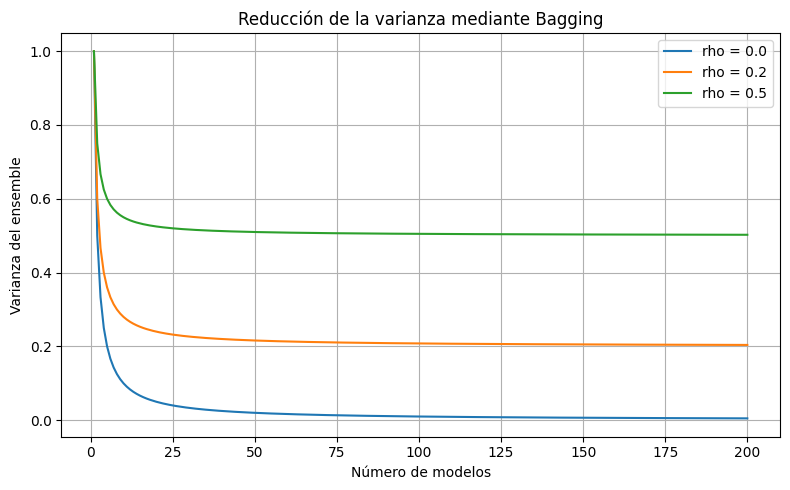

In [ ]:
sigma2 = 1.0
M = np.arange(1, 201)
rhos = [0.0, 0.2, 0.5]

plt.figure(figsize=(8, 5))

for rho in rhos:
    varianza = (sigma2 / M) * (1 - rho) + rho * sigma2
    plt.plot(M, varianza, label=f"rho = {rho}")

plt.xlabel("Número de modelos")
plt.ylabel("Varianza del ensemble")
plt.title("Reducción de la varianza mediante Bagging")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("figures/varianza_ensemble.png", dpi=300)
plt.show()

## 2. Voting Ensemble

En el Voting Ensemble se combinan las predicciones de varios clasificadores.

- En el **Hard Voting**, cada modelo emite una clase y gana la más votada.
- En el **Soft Voting**, se promedian las probabilidades predichas.

In [ ]:
X_voting, y_voting = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=17,
    n_redundant=3,
    random_state=3
)

modelos_voting = {
    "KNN-1": KNeighborsClassifier(n_neighbors=1),
    "KNN-3": KNeighborsClassifier(n_neighbors=3),
    "KNN-5": KNeighborsClassifier(n_neighbors=5),
    "KNN-7": KNeighborsClassifier(n_neighbors=7),
    "KNN-9": KNeighborsClassifier(n_neighbors=9)
}

estimadores = [
    ("knn1", KNeighborsClassifier(n_neighbors=1)),
    ("knn3", KNeighborsClassifier(n_neighbors=3)),
    ("knn5", KNeighborsClassifier(n_neighbors=5)),
    ("knn7", KNeighborsClassifier(n_neighbors=7)),
    ("knn9", KNeighborsClassifier(n_neighbors=9))
]

modelos_voting["Hard Voting"] = VotingClassifier(
    estimators=estimadores,
    voting="hard"
)

cv_voting = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=RND
)

resultados_voting = []
nombres_voting = []
resumen_voting = []

for nombre, modelo in modelos_voting.items():
    scores = cross_val_score(
        modelo,
        X_voting,
        y_voting,
        scoring="accuracy",
        cv=cv_voting,
        n_jobs=-1
    )

    resultados_voting.append(scores)
    nombres_voting.append(nombre)

    resumen_voting.append({
        "Modelo": nombre,
        "Accuracy media": scores.mean(),
        "Desviación estándar": scores.std()
    })

tabla_voting = pd.DataFrame(resumen_voting)
tabla_voting

,Modelo,Accuracy media,Desviación estándar
0,KNN-1,0.901667,0.032973
1,KNN-3,0.916667,0.028087
2,KNN-5,0.930000,0.024358
3,KNN-7,0.932333,0.021084
4,KNN-9,0.928667,0.027170
5,Hard Voting,0.934333,0.025256


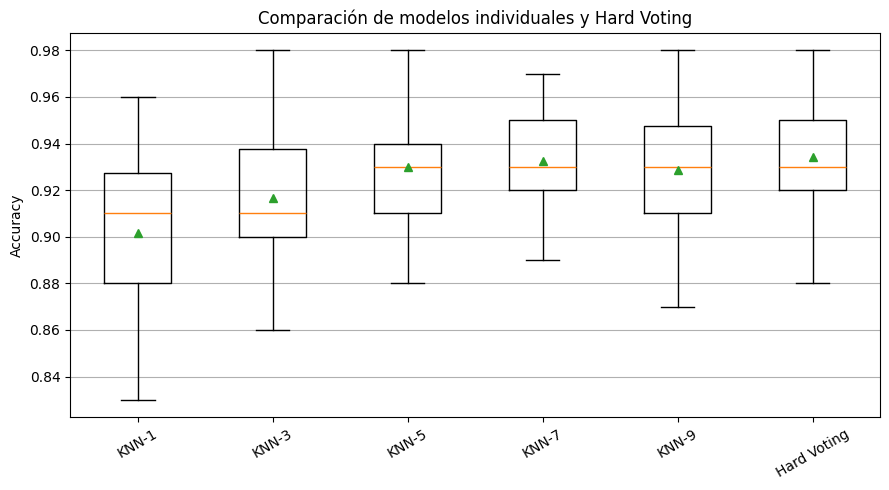

In [ ]:
plt.figure(figsize=(9, 5))
plt.boxplot(
    resultados_voting,
    tick_labels=nombres_voting,
    showmeans=True
)

plt.ylabel("Accuracy")
plt.title("Comparación de modelos individuales y Hard Voting")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("figures/comparacion_voting.png", dpi=300)
plt.show()

In [ ]:
tabla_voting.to_csv(
    "outputs/resultados_voting.csv",
    index=False
)

### Análisis

El Hard Voting combina las decisiones de diferentes configuraciones de KNN. La media de accuracy permite comparar su rendimiento, mientras que la desviación estándar representa la estabilidad obtenida durante la validación cruzada. El método Hard Voting obtuvo la mayor precisión promedio (0,9343), superando a todos los clasificadores KNN individuales. Esto evidencia que la combinación de múltiples modelos permite reducir errores individuales y mejorar la capacidad predictiva global. Además, la desviación estándar se mantuvo baja, indicando estabilidad durante la validación cruzada.

## 3. Boosting con AdaBoost

AdaBoost construye clasificadores de manera secuencial. Cada nuevo modelo presta mayor atención a las observaciones que fueron clasificadas incorrectamente por los modelos anteriores.

In [ ]:
X_boost, y_boost = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=6
)

cantidades_estimadores = [10, 50, 100, 500]

modelos_boosting = {
    str(n): AdaBoostClassifier(
        n_estimators=n,
        random_state=RND
    )
    for n in cantidades_estimadores
}

cv_boosting = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=RND
)

resultados_boosting = []
nombres_boosting = []
resumen_boosting = []

for nombre, modelo in modelos_boosting.items():
    scores = cross_val_score(
        modelo,
        X_boost,
        y_boost,
        scoring="accuracy",
        cv=cv_boosting,
        n_jobs=-1
    )

    resultados_boosting.append(scores)
    nombres_boosting.append(nombre)

    resumen_boosting.append({
        "Número de estimadores": int(nombre),
        "Accuracy media": scores.mean(),
        "Desviación estándar": scores.std()
    })

tabla_boosting = pd.DataFrame(resumen_boosting)
tabla_boosting

,Número de estimadores,Accuracy media,Desviación estándar
0,10,0.751333,0.032325
1,50,0.794333,0.026036
2,100,0.805667,0.026418
3,500,0.822000,0.031134


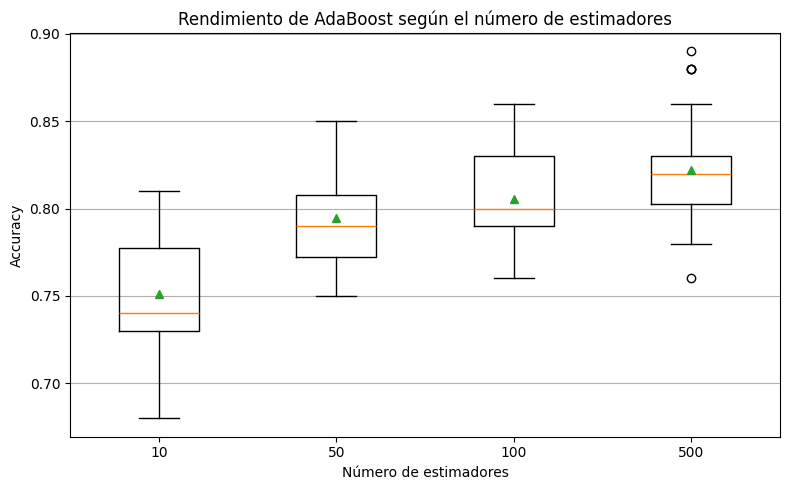

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    resultados_boosting,
    tick_labels=nombres_boosting,
    showmeans=True
)

plt.xlabel("Número de estimadores")
plt.ylabel("Accuracy")
plt.title("Rendimiento de AdaBoost según el número de estimadores")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("figures/comparacion_adaboost.png", dpi=300)
plt.show()

In [ ]:
tabla_boosting.to_csv(
    "outputs/resultados_adaboost.csv",
    index=False
)

### Análisis

El experimento permite observar cómo cambia el rendimiento de AdaBoost al aumentar el número de estimadores. Además de la accuracy promedio, se considera la desviación estándar para evaluar la estabilidad del modelo. Se observa una mejora progresiva del rendimiento de AdaBoost a medida que aumenta el número de estimadores. El mejor desempeño se obtuvo con 500 estimadores (accuracy = 0,8220). Esto confirma que el mecanismo de aprendizaje secuencial de AdaBoost permite corregir errores cometidos por modelos anteriores, incrementando gradualmente la precisión del conjunto.

# Desafío A: Comparación entre Random Forest y XGBoost

Se comparan dos algoritmos ensemble ampliamente utilizados utilizando el conjunto de datos Digits de Scikit-Learn.

Las métricas consideradas son:

- Accuracy promedio
- Desviación estándar
- Tiempo de entrenamiento

In [34]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [36]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X, y = load_digits(return_X_y=True)

modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.93333333 0.91666667 0.95543175 0.97214485 0.9275766 ]
0.9410306406685237


In [37]:
import time
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X, y = load_digits(return_X_y=True)

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

modelos = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    )
}

resumen = []
resultados = {}

for nombre, modelo in modelos.items():

    inicio = time.perf_counter()

    scores = cross_val_score(
        modelo,
        X,
        y,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1
    )

    tiempo = time.perf_counter() - inicio

    resultados[nombre] = scores

    resumen.append({
        "Modelo": nombre,
        "Accuracy media": scores.mean(),
        "Desviación estándar": scores.std(),
        "Tiempo (segundos)": tiempo
    })

tabla_desafio_a = pd.DataFrame(resumen)
tabla_desafio_a

,Modelo,Accuracy media,Desviación estándar,Tiempo (segundos)
0,Random Forest,0.978296,0.004901,17.831245
1,Gradient Boosting,0.968463,0.006085,206.125985


In [38]:
tabla_desafio_a.to_csv(
    "outputs/comparacion_rf_gradient_boosting.csv",
    index=False
)

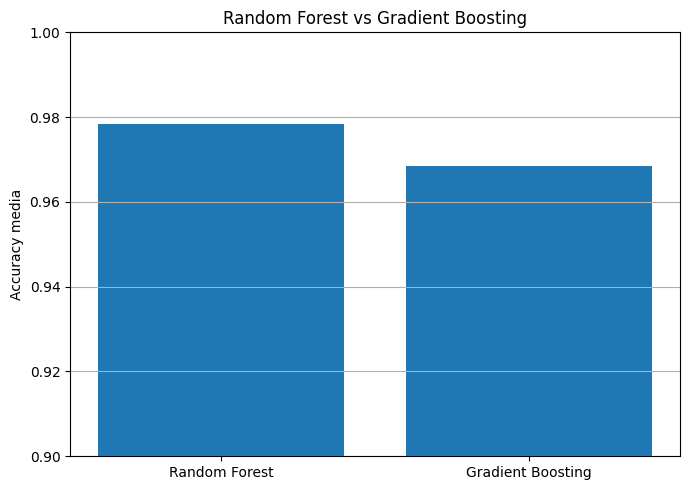

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(
    tabla_desafio_a["Modelo"],
    tabla_desafio_a["Accuracy media"]
)

plt.ylabel("Accuracy media")
plt.title("Random Forest vs Gradient Boosting")
plt.ylim(0.90, 1.00)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(
    "figures/rf_vs_gradient_boosting.png",
    dpi=300
)

plt.show()

### Análisis

Los resultados muestran que Random Forest obtuvo el mejor desempeño general, alcanzando una accuracy media de 0.9783 frente a 0.9685 de Gradient Boosting.

Además de presentar una mayor precisión, Random Forest mostró una menor desviación estándar (0.0049), lo que indica una mayor estabilidad durante la validación cruzada.

Respecto al tiempo de ejecución, Random Forest completó el entrenamiento y evaluación en aproximadamente 17.83 segundos, mientras que Gradient Boosting requirió 206.13 segundos.

En consecuencia, para este conjunto de datos, Random Forest ofrece una mejor relación entre precisión, estabilidad y costo computacional.

# Desafío B: Ensemble mediante Stacking

En este experimento se construye un modelo Stacking utilizando varios clasificadores base y un meta-modelo encargado de combinar sus predicciones.

Modelos base:

- Logistic Regression
- KNN
- Decision Tree

Meta-modelo:

- Logistic Regression

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [41]:
estimadores = [

    (
        "lr",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000))
        ])
    ),

    (
        "knn",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ])
    ),

    (
        "tree",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
]

In [42]:
stacking = StackingClassifier(

    estimators=estimadores,

    final_estimator=LogisticRegression(
        max_iter=2000
    ),

    cv=5,

    n_jobs=-1
)

In [43]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

cv_stack = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

modelos_stack = {

    "Logistic Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000))
        ]),

    "KNN":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Stacking":
        stacking
}

In [44]:
import time

resumen_stack = []
resultados_stack = []

for nombre, modelo in modelos_stack.items():

    inicio = time.perf_counter()

    scores = cross_val_score(
        modelo,
        X,
        y,
        scoring="accuracy",
        cv=cv_stack,
        n_jobs=-1
    )

    tiempo = time.perf_counter() - inicio

    resultados_stack.append(scores)

    resumen_stack.append({
        "Modelo": nombre,
        "Accuracy media": scores.mean(),
        "Desviación estándar": scores.std(),
        "Tiempo (segundos)": tiempo
    })

tabla_stack = pd.DataFrame(resumen_stack)

tabla_stack

,Modelo,Accuracy media,Desviación estándar,Tiempo (segundos)
0,Logistic Regression,0.969767,0.007577,3.022667
1,KNN,0.975700,0.005875,0.495773
2,Decision Tree,0.663308,0.029693,0.420048
3,Stacking,0.982750,0.005291,5.689386


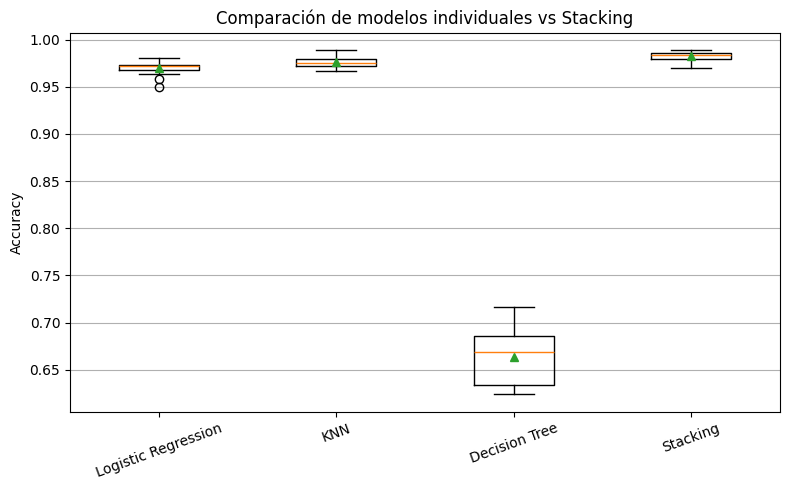

In [45]:
plt.figure(figsize=(8,5))

plt.boxplot(
    resultados_stack,
    tick_labels=tabla_stack["Modelo"],
    showmeans=True
)

plt.ylabel("Accuracy")
plt.title("Comparación de modelos individuales vs Stacking")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "figures/stacking_comparacion.png",
    dpi=300
)

plt.show()

In [46]:
tabla_stack.to_csv(
    "outputs/resultados_stacking.csv",
    index=False
)

### Análisis

El modelo Stacking obtuvo el mejor desempeño global, alcanzando una accuracy media de 0.9828, superior a la obtenida por todos los modelos individuales evaluados.

Entre los clasificadores base, KNN presentó el mejor rendimiento (0.9757), seguido por Logistic Regression (0.9698). Por otro lado, Decision Tree mostró un desempeño considerablemente inferior (0.6633).

La estrategia de Stacking permitió combinar las fortalezas de los distintos clasificadores mediante un meta-modelo basado en Logistic Regression. Como resultado, se logró incrementar la precisión y mantener una baja variabilidad entre particiones de validación cruzada.

Estos resultados muestran que la combinación de modelos puede generar predicciones más robustas que las obtenidas por un único clasificador.

# Informe Final

## Evaluación comparativa de métodos Ensemble para clasificación

### Objetivo

El presente trabajo tuvo como propósito analizar distintas estrategias de aprendizaje ensemble mediante experimentos de clasificación. Se evaluaron enfoques basados en Voting, Boosting y Stacking, considerando métricas obtenidas mediante validación cruzada. La comparación se centró en tres aspectos: capacidad predictiva, estabilidad de los resultados y costo computacional.

### Análisis de resultados

La primera etapa estuvo orientada al estudio de los métodos de votación. La comparación entre diferentes configuraciones de K-Nearest Neighbors mostró que el esquema Hard Voting alcanzó una accuracy media de **0,9343**, superior a la obtenida por cualquiera de los clasificadores individuales. Aunque la diferencia respecto a los mejores modelos base fue moderada, los resultados sugieren que la agregación de predicciones contribuye a disminuir errores particulares de cada clasificador y favorece una mayor consistencia en la respuesta final del sistema.

Posteriormente se analizó AdaBoost utilizando distintos números de estimadores. Los resultados evidenciaron una tendencia creciente del rendimiento conforme aumentó la complejidad del ensemble. La accuracy media evolucionó desde **0,7513** con 10 estimadores hasta **0,8220** con 500 estimadores. Este comportamiento refleja la capacidad de los métodos boosting para concentrar progresivamente el aprendizaje en aquellas observaciones que presentan mayores dificultades de clasificación. El incremento de precisión obtenido no fue lineal, lo que indica una disminución gradual de los beneficios marginales a medida que se incorporan nuevos estimadores.

La comparación entre Random Forest y Gradient Boosting se realizó utilizando el conjunto de datos Digits. Random Forest obtuvo una accuracy media de **0,9783**, acompañada por una desviación estándar de **0,0049**. Gradient Boosting alcanzó una accuracy media de **0,9685** con una desviación estándar de **0,0061**. Aunque ambos modelos presentaron niveles de desempeño elevados, Random Forest mostró una ventaja tanto en precisión como en estabilidad. La diferencia más significativa se observó en el tiempo de ejecución: aproximadamente **17,83 segundos** para Random Forest frente a **206,13 segundos** para Gradient Boosting. Esta disparidad pone de manifiesto la importancia de incorporar métricas de eficiencia computacional en la evaluación de modelos, especialmente cuando se consideran escenarios de despliegue o actualización frecuente.

La última etapa estuvo dedicada a la construcción de un modelo Stacking. Se utilizaron Logistic Regression, KNN y Decision Tree como clasificadores base, mientras que Logistic Regression fue empleada como meta-modelo. El ensemble alcanzó una accuracy media de **0,9828** y una desviación estándar de **0,0053**, constituyendo el mejor desempeño global entre todos los experimentos realizados. Este resultado supera a cada uno de los clasificadores individuales evaluados, incluido KNN, que fue el modelo base con mejor rendimiento. Este comportamiento indica que las predicciones generadas por distintos algoritmos contienen información complementaria que puede ser aprovechada por el meta-modelo para reducir errores residuales y mejorar la capacidad de generalización.

### Discusión

Los experimentos realizados permiten observar que el incremento de diversidad entre modelos favorece el rendimiento de los ensembles. Las estrategias de combinación estudiadas operan bajo principios distintos: Voting integra decisiones independientes, Boosting corrige errores de forma secuencial y Stacking aprende explícitamente cómo combinar las salidas de varios modelos.

Los resultados muestran que la magnitud de la mejora obtenida depende tanto de la heterogeneidad de los clasificadores como del mecanismo utilizado para integrarlos. Mientras que Hard Voting produjo mejoras moderadas respecto a los modelos base, Stacking logró aprovechar de manera más eficiente las diferencias entre algoritmos, alcanzando el mayor nivel de precisión observado durante el estudio.

Desde una perspectiva práctica, el desempeño predictivo no constituye el único criterio de evaluación. La complejidad computacional, los tiempos de entrenamiento y la facilidad de mantenimiento también deben ser considerados durante la selección de un modelo. Bajo esta perspectiva, Random Forest presentó una relación particularmente favorable entre precisión, estabilidad y costo computacional.

### Recomendaciones para producción

Para aplicaciones donde el objetivo prioritario sea maximizar la capacidad predictiva, el modelo **Stacking** representa la alternativa más conveniente, dado que alcanzó la mayor accuracy media y mantuvo una variabilidad reducida entre particiones de validación cruzada.

En entornos donde la eficiencia computacional y la simplicidad operativa tengan mayor peso en la toma de decisiones, **Random Forest** constituye una opción altamente competitiva. Su desempeño se mantuvo muy próximo al mejor modelo evaluado, con tiempos de ejecución considerablemente menores y una estabilidad destacable.

Los resultados obtenidos evidencian que las estrategias ensemble ofrecen ventajas significativas frente al uso de clasificadores individuales y que la combinación adecuada de modelos permite alcanzar niveles de desempeño difíciles de obtener mediante un único algoritmo.